### Step 1: Load the Excel file

In [1]:
import pandas as pd

df = pd.read_excel('default_of_credit_card_clients.xls', header=1)

display(df.head())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [2]:
# Quick check
print(df.shape)
print(df.columns)

(30000, 25)
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')


In [3]:
df['EDUCATION'].unique()

array([2, 1, 3, 5, 4, 6, 0], dtype=int64)

### Check for Null Values and Duplicates

In [4]:
# Check for null values
null_counts = df.isnull().sum()
print("Null values per column:")
display(null_counts[null_counts > 0])

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")

Null values per column:


Series([], dtype: int64)


Number of duplicate rows: 0


In [5]:
# Rename target column for clarity
df.rename(columns={"default payment next month": "default"}, inplace=True)

In [6]:
df['EDUCATION_name'] = df['EDUCATION'].map({
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Others",
    5: "Others",
    6: "Others"
})


In [7]:
numeric_cols = [
    'LIMIT_BAL', 'AGE',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

# Compute summary statistics (mean, std, min, max, and quartiles including median) using .describe()
summary_stats = df[numeric_cols].describe()

# Compute median separately for direct addition as a row
median_values = df[numeric_cols].median()

# Create a Series for the median and add it to the summary_stats DataFrame
summary_stats.loc['median'] = median_values

display(summary_stats)

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,9.217904,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,21.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,34.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,41.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,79.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000
median,140000.000000,34.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000


### Examine the distribution of the target variable

We will now examine the distribution of the target variable `default` to confirm the class imbalance.

In [8]:
# Calculate the distribution of the 'default' target variable
default_counts = df['default'].value_counts()
default_percentages = df['default'].value_counts(normalize=True) * 100

# Combine counts and percentages into a single DataFrame
combined_default_distribution = pd.DataFrame({
    'Count': default_counts,
    'Percentage': default_percentages
})

print("Distribution of 'default' target variable (counts and percentages):")
display(combined_default_distribution)

print(f"\nClass Imbalance Confirmed:\nDefault (1): {default_percentages[1]:.2f}% of clients\nNon-default (0): {default_percentages[0]:.2f}% of clients")

Distribution of 'default' target variable (counts and percentages):


,Count,Percentage
default,,
0,23364,77.88
1,6636,22.12



Class Imbalance Confirmed:
Default (1): 22.12% of clients
Non-default (0): 77.88% of clients


## Visualization

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

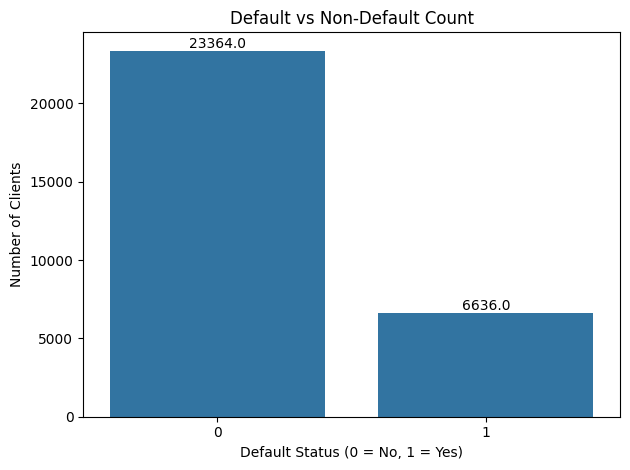

In [10]:
plt.figure()
ax = sns.countplot(x="default", data=df)
plt.title("Default vs Non-Default Count")
plt.xlabel("Default Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Clients")

# Add numbers on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

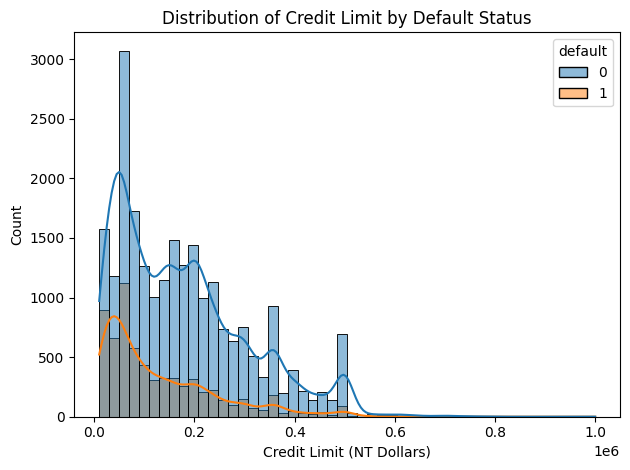

In [11]:
plt.figure()
sns.histplot(data=df, x="LIMIT_BAL", hue="default", bins=50, kde=True)
plt.title("Distribution of Credit Limit by Default Status")
plt.xlabel("Credit Limit (NT Dollars)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Default Rate by Age Group

In [12]:
# Define age bins and labels
age_bins = [20, 30, 40, 50, 60, 70, 80]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']

# Create 'AGE_GROUP' column
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=age_bins, labels=age_labels, right=False)

# Calculate default rate by age group
default_rate_age = (
    df.groupby("AGE_GROUP")["default"]
    .mean()
    .reset_index()
    .rename(columns={"default": "default_rate"})
)

display(default_rate_age)

C:\Users\Admin\AppData\Local\Temp\ipykernel_22636\2884484602.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AGE_GROUP")["default"]


,AGE_GROUP,default_rate
0,20-29,0.228426
1,30-39,0.202527
2,40-49,0.229734
3,50-59,0.248612
4,60-69,0.283439
5,70-79,0.280000


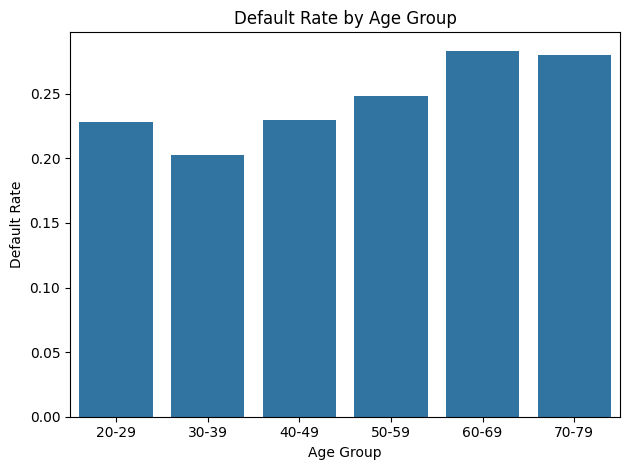

In [13]:
plt.figure()
sns.barplot(data=default_rate_age, x="AGE_GROUP", y="default_rate")
plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate")
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_22636\2837083178.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


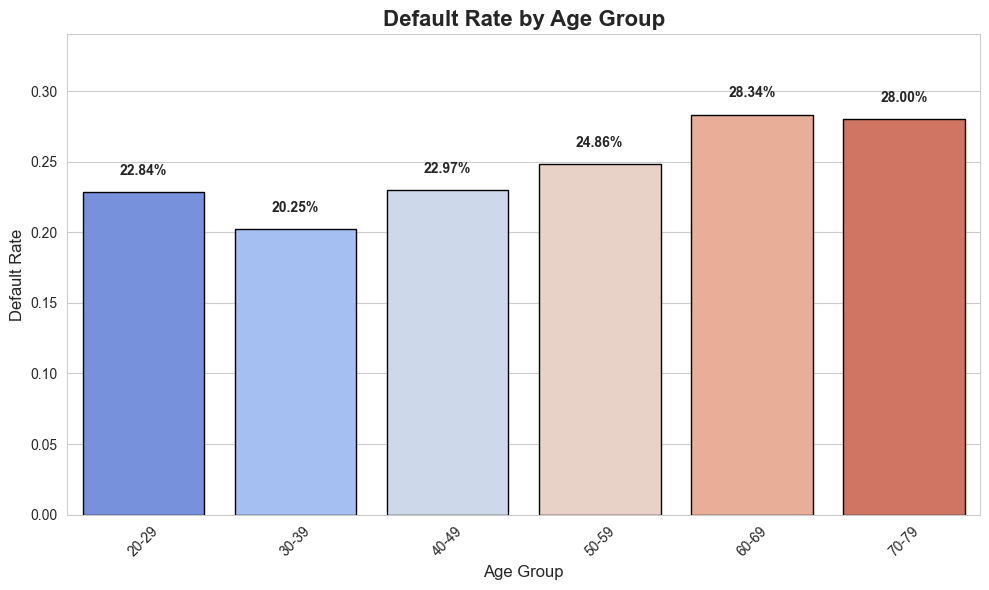

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

# Colorful barplot
bars = sns.barplot(
    data=default_rate_age, 
    x="AGE_GROUP", 
    y="default_rate", 
    palette="coolwarm", 
    edgecolor="black"
)

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # x position
        height + 0.01,                     # y position slightly above the bar
        f'{height:.2%}',                   # format as percentage
        ha='center', 
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Default Rate by Age Group", fontsize=16, fontweight='bold')
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Default Rate", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, max(default_rate_age['default_rate'])*1.2)  # space for labels
plt.tight_layout()
plt.show()


### Default Rate by Education Level

,EDUCATION_name,default_rate
0,Graduate School,0.192348
1,High School,0.251576
2,Others,0.072687
3,University,0.237349


C:\Users\Admin\AppData\Local\Temp\ipykernel_22636\2386223224.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=default_rate_edu, x="EDUCATION_name", y="default_rate", palette="viridis")


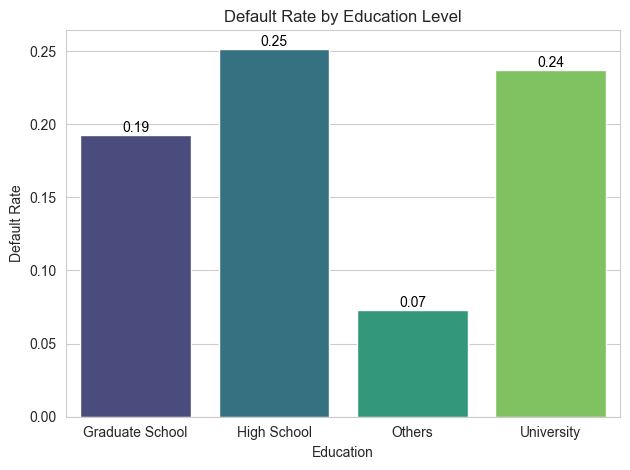

In [15]:
default_rate_edu = (
    df.groupby("EDUCATION_name")["default"]
    .mean()
    .reset_index()
    .rename(columns={"default": "default_rate"})
)

display(default_rate_edu)

plt.figure()
ax = sns.barplot(data=default_rate_edu, x="EDUCATION_name", y="default_rate", palette="viridis")
plt.title("Default Rate by Education Level")
plt.xlabel("Education")
plt.ylabel("Default Rate")

# Add numbers on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### Correlation Heatmap of Selected Variables

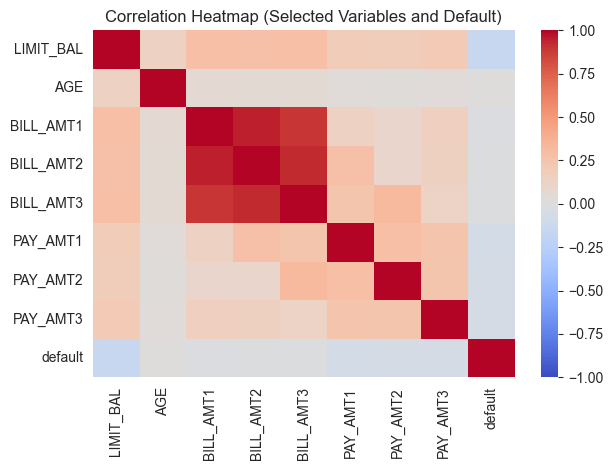

In [16]:
# Select variables for correlation analysis
corr_vars = [
    "LIMIT_BAL", "AGE", "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "default"
]

# Compute correlation matrix
corr = df[corr_vars].corr()

# Plot heatmap
plt.figure()
sns.heatmap(corr, annot=False, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Selected Variables and Default)")
plt.tight_layout()
plt.show()

In [17]:
# Define the path to save the CSV file in your Google Drive
#output_path = 'processed_default_credit.xlsx'

# Export the DataFrame to CSV
#df.to_excel(output_path, index=False)

#print(f"DataFrame successfully exported to '{output_path}'")